In [11]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report,
)


In [12]:
def load_and_preprocess_data(data_path, label_column_name, sample_fraction=0.1):
    # Load all CSV files from the directory
    all_files = glob.glob(os.path.join(data_path, '*.csv'))

    df_list = []
    print("Loading CSV files...")
    for filename in all_files:
        temp_df = pd.read_csv(filename)
        df_list.append(temp_df)

    df = pd.concat(df_list, ignore_index=True)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Check and update label column name if necessary
    if label_column_name not in df.columns:
        possible_label_columns = [col for col in df.columns if 'label' in col.lower()]
        if possible_label_columns:
            label_column_name = possible_label_columns[0]
            print(f"Using '{label_column_name}' as the label column.")
        else:
            raise KeyError(f"Label column '{label_column_name}' not found in dataframe.")

    # Map labels to 'Benign' and 'Malicious'
    df[label_column_name] = np.where(df[label_column_name] == 'BENIGN', 'Benign', 'Malicious')

    # Stratified sampling to maintain class distribution
    df = df.groupby(label_column_name, group_keys=False).apply(
        lambda x: x.sample(frac=sample_fraction, random_state=42)
    ).reset_index(drop=True)

    # Separate features and labels
    X = df.drop(columns=[label_column_name])
    y = df[label_column_name]

    return X, y


In [13]:
def preprocess_and_split(X, y, test_size=0.2, random_state=42):
    # Convert categorical features to numeric if any
    X = pd.get_dummies(X)

    # Identify numeric columns
    numeric_cols = X.select_dtypes(include=['float64', 'int64', 'uint8']).columns

    # Handle infinite values
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Impute missing values using median
    imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

    # Scale features using Min-Max Scaler
    scaler = MinMaxScaler()
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Split data with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
 # Encode labels for multiclass classification
    y_encoded = label_encoder.fit_transform(y)
    y_encoded = to_categorical(y_encoded)

    # Split data with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_encoded, test_size=test_size, random_state=random_state, stratify=y
    )

    # Reshape data for CNN input (samples, time steps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    return X_train, X_test, y_train, y_test, label_encoder.classes_


In [14]:
def correlation_selection(X, y, feature_number=10):
    # Combine X and y into a single DataFrame
    df = X.copy()
    df['Target'] = y

    # Calculate correlation matrix
    corr_matrix = df.corr()

    # Get correlation with target variable
    corr_with_target = corr_matrix['Target'].drop('Target')

    # Select top features based on absolute correlation
    top_features = corr_with_target.abs().sort_values(ascending=False).head(feature_number).index.tolist()

    print(f"Top {feature_number} features selected by correlation:")
    print(top_features)

    return top_features


In [15]:
def univariate_selection(X, y, feature_number=10):
    selector = SelectKBest(score_func=f_classif, k=feature_number)
    selector.fit(X, y)

    selected_indices = selector.get_support(indices=True)
    selected_features = X.columns[selected_indices].tolist()

    print(f"Top {feature_number} features selected by univariate selection:")
    print(selected_features)

    return selected_features


In [16]:
def random_forest_selection(X, y, feature_number=10):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    importances = model.feature_importances_
    feature_importance = pd.Series(importances, index=X.columns)
    top_features = feature_importance.sort_values(ascending=False).head(feature_number).index.tolist()

    print(f"Top {feature_number} features selected by Random Forest importance:")
    print(top_features)

    return top_features


In [17]:
def extra_trees_selection(X, y, feature_number=10):
    model = ExtraTreesClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    importances = model.feature_importances_
    feature_importance = pd.Series(importances, index=X.columns)
    top_features = feature_importance.sort_values(ascending=False).head(feature_number).index.tolist()

    print(f"Top {feature_number} features selected by Extra Trees importance:")
    print(top_features)

    return top_features


In [18]:
def train_and_evaluate_model(X_train, X_test, y_train, y_test, class_names):
    num_classes = y_train.shape[1]
    input_shape = (X_train.shape[1], 1)

    # Define the CNN model
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu'))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("\nTraining the CNN model...")
    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

    # Evaluate the model
    scores = model.evaluate(X_test, y_test, verbose=0)
    print("\nModel Performance:")
    print(f"Test Loss: {scores[0]:.4f}")
    print(f"Test Accuracy: {scores[1]:.4f}")

    # Predict classes
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=-1)
    y_true_classes = y_test.argmax(axis=-1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


In [19]:
def main():
    data_path = r'C:\Users\joshb\OneDrive\Documents\Final Project\CICDS 2017\MachineLearningCVE'
    label_column_name = 'Label'  # Update if necessary
    sample_fraction = 1.0  # Adjust sample fraction as needed

    # Step 1: Load and preprocess data
    print("Loading and preprocessing data...")
    X, y = load_and_preprocess_data(data_path, label_column_name, sample_fraction)

    # Step 2: Preprocess and split data
    print("Preprocessing and splitting data...")
    X_train, X_test, y_train, y_test, class_names = preprocess_and_split(X, y)

    # Step 4: Train and evaluate the CNN model
    train_and_evaluate_model(X_train, X_test, y_train, y_test, class_names)



Loading and preprocessing data...
Loading CSV files...


C:\Users\joshb\AppData\Local\Temp\ipykernel_22804\1045947770.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(label_column_name, group_keys=False).apply(


Preprocessing and splitting data...


C:\Users\joshb\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training the CNN model...
Epoch 1/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 195s 3ms/step - accuracy: 0.9642 - loss: 0.0824 - val_accuracy: 0.9819 - val_loss: 0.0397
Epoch 2/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 194s 3ms/step - accuracy: 0.9829 - loss: 0.0393 - val_accuracy: 0.9873 - val_loss: 0.0315
Epoch 3/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 193s 3ms/step - accuracy: 0.9851 - loss: 0.0356 - val_accuracy: 0.9839 - val_loss: 0.0330
Epoch 4/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 133s 2ms/step - accuracy: 0.9901 - loss: 0.0275 - val_accuracy: 0.9955 - val_loss: 0.0193
Epoch 5/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 133s 2ms/step - accuracy: 0.9902 - loss: 0.0271 - val_accuracy: 0.9955 - val_loss: 0.0179
Epoch 6/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 133s 2ms/step - accuracy: 0.9896 - loss: 0.0278 - val_accuracy: 0.9958 - val_loss: 0.0167
Epoch 7/10
63692/63692 ━━━━━━━━━━━━━━━━━━━━ 188s 3ms/step - accuracy: 0.9897 - loss: 0.0290 - val_accuracy: 0.9954 - val_loss: 0.0233
Epoch 8/10
63692/63692 ━━━━━━━━━━━━

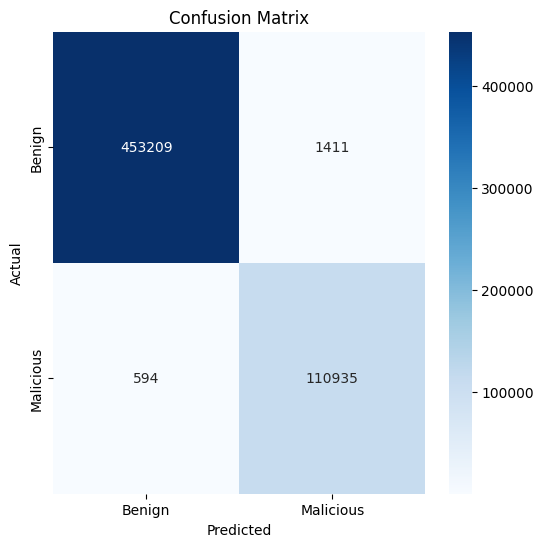

In [20]:
if __name__ == "__main__":
    main()
